## Loading experiment results

In Mozaik, experiment results are stored in a database called Data Store. In its current implementation, the DataStore is stored as a collection of .pickle files in the results directory of the simulation. It is stored in the following files:

- SegmentX.pickle - Used for storing neural recordings. For each stimulus and each sheet you record from, one Segment is created. So with 2 LGN sheets (ON & OFF cells), and 4 cortical sheets (excitatory and inhibitory cells of Layer 4 and Layer 2/3), 6 Segments are created for each stimulus, as we record some neural activity from all simulated sheets.
- datastore.recordings.pickle - Used for storing references and metadata for the segments. Indispensable for loading the datastore.
- datastore.analysis.pickle - Used for storing analysis results. 
- datastore.sensory.stimulus.pickle - Used for storing the visual stimuli used in experiments. Most of the time almost empty, as we don't store those by default.


Once a simulation has successfully run, you should see all datastore files and at least one Segment in the results directory. If they are not there (especially if you see Segments but no datastore files), the simulation most likely crashed for some reason and needs to be rerun.

In [1]:
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query
from mozaik.tools.distribution_parametrization import load_parameters
import logging
import sys
from mozaik.storage.queries import *
from mozaik.analysis.analysis import *
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
from mozaik.storage.datastore import DataStoreView
import matplotlib.pyplot as plt
import numpy as np
import ast

# Path to the experiment DataStore
# Substitute this path with the path of your own simulation run!
# path = "SelfSustainedPushPull_test_____"
path = "SelfSustainedPushPull_test:fullbig32_32_____"

data_store = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
    replace=False,
)

data_store.print_content()

dsv = param_filter_query(
        data_store, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3"
    )
dsv.print_content()
segs = dsv.get_segments()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 864
INFO:Mozaik:     InternalStimulus : 480
INFO:Mozaik:     PixelMovieExperanto : 384
INFO:Mozaik:   Number of ADS: 0
INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 64
INFO:Mozaik:     PixelMovieExperanto : 64
INFO:Mozaik:   Number of ADS: 0


## Datastore contents - LSV1M

If you ran the experiments for the first version of our model (LSV1M), you should see all stimuli (InternalStimulus, FullfieldDriftingSinusoidalGrating, NaturalImageWithEyeMovement, EndOfSimulationBlank) below. Additionally, you can see the analysis results (Analysis Data Structures - ADS) saved into the data store.

In [2]:
print("Sample content of Stimulus annotation:")
print(ast.literal_eval(segs[0].annotations['stimulus']))
print('-'*50)

segs, stims = dsv.get_segments(), dsv.get_stimuli()
for i in range(len(segs)):
    print(f"Segment {i}:", ast.literal_eval(segs[i].annotations['stimulus'])['trial'], ast.literal_eval(segs[i].annotations['stimulus'])['movie_name'], ast.literal_eval(segs[i].annotations['stimulus'])['duration'])
print('-'*50)

Sample content of Stimulus annotation:
{'module_path': 'mozaik.stimuli.vision.topographica_based', 'background_luminance': 50.0, 'density': 13.090907186777137, 'direct_stimulation_name': None, 'direct_stimulation_parameters': None, 'duration': 497.0, 'frame_duration': 7.0, 'frame_offset': 0, 'location_x': 0.0, 'location_y': 0.0, 'movie_frame_duration': 497.0, 'movie_name': '00095.npy', 'movie_path': '/data/dynamic29513-3-5-Video-full/screen/data', 'name': 'PixelMovieExperanto', 'size': 11, 'size_x': 11.0, 'size_y': 11.0, 'trial': 0, 'video_max_value': 255.0, 'x_location': 0.0, 'y_location': 0.0}
--------------------------------------------------
Segment 0: 0 00095.npy 497.0
Segment 1: 2 00098.npy 2205
Segment 2: 2 00083.npy 497.0
Segment 3: 1 00086.npy 497.0
Segment 4: 2 00099.npy 2100
Segment 5: 3 00089.npy 497.0
Segment 6: 0 00089.npy 497.0
Segment 7: 0 00097.npy 2100
Segment 8: 3 00097.npy 2100
Segment 9: 2 00092.npy 497.0
Segment 10: 1 00095.npy 497.0
Segment 11: 0 00098.npy 2205
S

In [5]:
# 1. Retrieve data
bin_size = 1 / 8 * 1000

# 2. First Pass: Scan for Metadata
all_movie_names = set()
max_duration = 0.0
max_trial_index = 0

for s in segs:
    params = ast.literal_eval(s.annotations['stimulus'])
    all_movie_names.add(params['movie_name'])
    if params['duration'] > max_duration:
        max_duration = params['duration']
    if int(params['trial']) > max_trial_index:
        max_trial_index = int(params['trial'])

unique_movies = sorted(list(all_movie_names))
movie_to_index = {name: i for i, name in enumerate(unique_movies)}

num_trials = max_trial_index + 1
num_stimuli = len(unique_movies)
num_neurons = len(segs[0].get_spiketrains())
num_bins = int(np.ceil(max_duration / bin_size))

print(f"Array Shape: ({num_trials}, {num_stimuli}, {num_neurons}, {num_bins})")

# 3. Initialize with NaNs (Standard for 'missing' data)
# Note: This forces the array to be float type
spikes_all_stimuli = np.full((num_trials, num_stimuli, num_neurons, num_bins), np.nan)

# 4. Second Pass: Fill the Data
for i, seg in enumerate(segs):
    print(f"Processing Segment {i+1}/{len(segs)}")
    stim_params = ast.literal_eval(seg.annotations['stimulus'])
    
    trial_idx = int(stim_params['trial'])
    stim_idx = movie_to_index[stim_params['movie_name']]
    current_segment_duration = stim_params['duration']
    
    # Calculate how many bins strictly belong to THIS segment
    num_segment_bins = int(np.ceil(current_segment_duration / bin_size))
    
    for k in range(num_neurons):
        spike_times = np.array(seg.get_spiketrains()[k])
        
        # Filter valid spikes
        valid_spikes = spike_times[spike_times < current_segment_duration]
        
        # Calculate indices
        spike_indices = (valid_spikes // bin_size).astype(int)
        valid_indices_mask = spike_indices < num_segment_bins
        final_indices = spike_indices[valid_indices_mask]
        
        # Get counts for the valid window only
        counts = np.bincount(final_indices, minlength=num_segment_bins)
        
        # Trim just in case
        counts = counts[:num_segment_bins]
        
        # --- Assignment Logic for NaNs ---
        # We need to handle the existing NaNs. 
        # If the slot is currently NaN, treat it as 0 before adding the new counts.
        
        # 1. Get the slice of the array that corresponds to valid time
        current_data = spikes_all_stimuli[trial_idx, stim_idx, k, :num_segment_bins]
        
        # 2. Replace NaNs with 0 so we can add (if this is the first segment, they are all Nan)
        current_data = np.nan_to_num(current_data, nan=0.0)
        
        # 3. Add the new counts and write back
        spikes_all_stimuli[trial_idx, stim_idx, k, :num_segment_bins] = current_data + counts

print("Final array shape:", spikes_all_stimuli.shape)
print("Example of padding (last 5 bins of first entry):", spikes_all_stimuli[0, 0, 0, -5:])

Array Shape: (4, 8, 38150, 18)
Processing Segment 1/32
Processing Segment 2/32
Processing Segment 3/32
Processing Segment 4/32
Processing Segment 5/32
Processing Segment 6/32
Processing Segment 7/32
Processing Segment 8/32
Processing Segment 9/32
Processing Segment 10/32
Processing Segment 11/32
Processing Segment 12/32
Processing Segment 13/32
Processing Segment 14/32
Processing Segment 15/32
Processing Segment 16/32
Processing Segment 17/32
Processing Segment 18/32
Processing Segment 19/32
Processing Segment 20/32
Processing Segment 21/32
Processing Segment 22/32
Processing Segment 23/32
Processing Segment 24/32
Processing Segment 25/32
Processing Segment 26/32
Processing Segment 27/32
Processing Segment 28/32
Processing Segment 29/32
Processing Segment 30/32
Processing Segment 31/32
Processing Segment 32/32
Final array shape: (4, 8, 38150, 18)
Example of padding (last 5 bins of first entry): [nan nan nan nan nan]


In [9]:
np.unique(spikes_all_stimuli)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7., nan])

In [10]:
if False:
    print("="*30, "Old Code Below for Reference", "="*30)
    bin_size = 1 / 8 * 1000
    duration = load_parameters(stims[0])["duration"]
    num_trials = load_parameters(data_store.get_experiment_parametrization_list()[0][1])["num_trials"]
    
    spikes_all_stimuli = np.zeros((num_trials, len(segs)//num_trials, len(segs[0].get_spiketrains()), int(np.ceil(duration/bin_size))))
    num_trials = spikes_all_stimuli.shape[0]
    num_stimuli = spikes_all_stimuli.shape[1]
    for i in range(num_trials): # Number of trials 
        for j in range(num_stimuli): # Number of Stimuli
            segment_index = i * num_stimuli + j
            for k in range(spikes_all_stimuli.shape[2]): # Number of neurons
                spike_times = np.array(segs[segment_index].get_spiketrains()[k])
                valid_spikes = spike_times[spike_times < duration]
                spike_indices, counts = np.unique(valid_spikes // bin_size, return_counts=True)
                spikes_all_stimuli[i,j,k,spike_indices.astype(int)] += counts
    print(spikes_all_stimuli.shape)

In [11]:
i = 1
k = 5
print(segs[i].get_spiketrains()[k])
segs[i].get_spiketrains()[k]

[253.7] ms


SpikeTrain containing 1 spikes; units ms; datatype float64 
annotations: {'source_population': 'V1_Exc_L2/3',
  'source_id': 170672,
  'source_index': 11,
  'channel_id': 170672}
time: 0.0 ms to 497.0 ms

In [12]:
num_spikes = []
for neuron in range(len(segs[0].get_spiketrains())):
    # print(np.array(segs[i].get_spiketrains()[neuron]))
    a = len(segs[i].get_spiketrains()[neuron])
    num_spikes.append(a)

<BarContainer object of 16 artists>

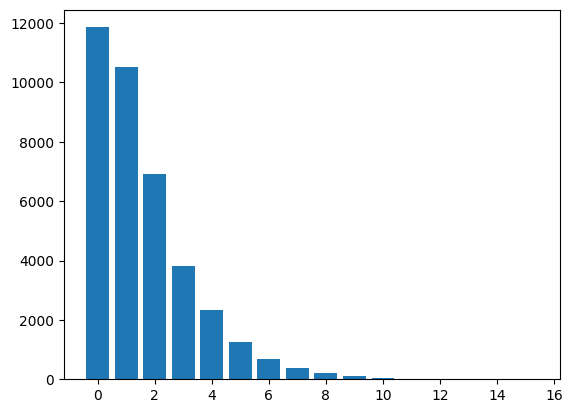

In [13]:
unique, counts = np.unique(num_spikes, return_counts=True)
plt.bar(unique, counts)

In [14]:
np.array(segs[i].get_spiketrains()[4323])

array([229.8, 443.6])

In [31]:
(spikes_all_stimuli[0][2] == spikes_all_stimuli[1][0]).all() # ALL the stimuli have the same pattern.

False

In [36]:
spikes_all_stimuli[0][5]

(38150, 4)

In [37]:
load_parameters(stims[0])

{'module_path': 'mozaik.stimuli.vision.topographica_based',
 'background_luminance': 50.0,
 'density': 13.090907186777137,
 'direct_stimulation_name': None,
 'direct_stimulation_parameters': None,
 'duration': 497.0,
 'frame_duration': 7.0,
 'frame_offset': 0,
 'location_x': 0.0,
 'location_y': 0.0,
 'movie_frame_duration': 497.0,
 'movie_name': '00055.npy',
 'movie_path': '/data/dynamic29513-3-5-Video-full/screen/data',
 'name': 'PixelMovieExperanto',
 'size': 11,
 'size_x': 11.0,
 'size_y': 11.0,
 'trial': 1,
 'video_max_value': 255.0,
 'x_location': 0.0,
 'y_location': 0.0}

In [38]:
len(segs)//num_trials

8

In [18]:
segs[0]

PickledDataStoreNeoWrapper with 38150 spiketrains
name: 'segment000'
description: 'Population "V1_Exc_L2/3"\n    Structure   : RandomStructure\n    Local cells : 125000\n    Cell type   : EIF_cond_exp_isfa_ista\n    ID range    : 170661-295660\n    First cell on this node:\n      ID: 170661\n      {}'
annotations: {'sheet_name': 'V1_Exc_L2/3',
  'stimulus': '{"module_path" :"mozaik.stimuli.vision.topographica_based","background_luminance":50.0, "density":13.090907186777137, "direct_stimulation_name":None, "direct_stimulation_parameters":None, "duration":497.0, "frame_duration":7.0, "frame_offset":0, "location_x":0.0, "location_y":0.0, "movie_frame_duration":497.0, "movie_name":\'00055.npy\', "movie_path":\'/data/dynamic29513-3-5-Video-full/screen/data\', "name":\'PixelMovieExperanto\', "size":11, "size_x":11.0, "size_y":11.0, "trial":1, "video_max_value":255.0, "x_location":0.0, "y_location":0.0}'}
# analogsignals (N=0)

In [1]:
# import numpy as np
# import yaml
# import os
# import ast
# import gc
# import psutil
# from scipy.ndimage import gaussian_filter1d

# def get_process_memory():
#     """Returns current process memory usage in MB."""
#     process = psutil.Process(os.getpid())
#     return process.memory_info().rss / 1024 / 1024

# def export_mozaik_trial_streamed(dsv_or_list, output_dir, trial_id, sampling_rate=1000.0, 
#                                  smooth_param=None):
#     """
#     Exports a single trial from one or more Mozaik DataStoreView (dsv) objects to disk using streaming.
    
#     Args:
#         dsv_or_list: A single Mozaik DataStoreView object or a list of them.
#         output_dir: Folder to save outputs.
#         trial_id: The specific trial ID to export.
#         sampling_rate: Sampling rate in Hz.
#         smooth_param: Dictionary with 'sigma' and 'window' keys, or None to disable smoothing.
#     """
    
#     print(f"Initial Memory Usage: {get_process_memory():.2f} MB")

#     # Handle single dsv or list of dsvs
#     if isinstance(dsv_or_list, (list, tuple)):
#         dsvs = dsv_or_list
#     else:
#         dsvs = [dsv_or_list]

#     # --- 1. First Pass: Metadata Scan (Lightweight) ---
#     # We need to know the total duration and stimulus order to set up the output file.
#     # Mozaik's get_segments() returns lazy objects or references.
    
#     print("Scanning metadata...")
    
#     trial_segments = []
    
#     for dsv in dsvs:
#         segment_refs = dsv.get_segments() # Assuming this is a list of lazy objects or light references
    
#         for seg in segment_refs:
#             try:
#                 # Mozaik annotations are sometimes strings, sometimes dictionaries depending on version/storage
#                 if isinstance(seg.annotations['stimulus'], str):
#                     stim_params = ast.literal_eval(seg.annotations['stimulus'])
#                 else:
#                     stim_params = seg.annotations['stimulus']
#             except (ValueError, SyntaxError):
#                  # Fallback if ast.literal_eval fails (e.g. Mozaik ParameterSet string)
#                  print(f"Warning: Could not parse stimulus annotation for segment {seg}. Skipping check.")
#                  continue

#             if int(stim_params['trial']) == trial_id:
#                 trial_segments.append({
#                     'segment': seg, # Keep reference
#                     'stim_name': stim_params.get('movie_name', stim_params.get('name', 'unknown')),
#                     'duration': stim_params['duration']
#                 })

#     if not trial_segments:
#         raise ValueError(f"No segments found for Trial {trial_id}")

#     # Sort by stimulus name
#     # Note: If multiple DSVs contain the SAME stimulus segment (e.g. MPI split neurons), 
#     # this logic will treat them as sequential time blocks. This script assumes 
#     # segments represent distinct time intervals.
#     trial_segments.sort(key=lambda x: x['stim_name'])
    
#     print(f"Memory after metadata scan: {get_process_memory():.2f} MB")

#     # Calculate dimensions
#     # Assuming all segments have the same units
#     # We need to load one segment to count units if not known
#     # Be careful with get_spiketrains() triggering load
#     test_seg = trial_segments[0]['segment']
#     num_units = len(test_seg.get_spiketrains()) # This might load data for this segment
    
#     # Explicitly release if possible to keep memory clean
#     if hasattr(test_seg, 'release'):
#         test_seg.release()

#     durations = [x['duration'] for x in trial_segments]
#     total_duration_ms = sum(durations)
#     total_bins = int(np.ceil(total_duration_ms * (sampling_rate / 1000.0)))
#     bin_size_ms = 1000.0 / sampling_rate
    
#     print(f"Trial {trial_id}: {len(trial_segments)} stimuli, {num_units} units, {total_bins} bins")
#     print(f"Memory after init calc: {get_process_memory():.2f} MB")

#     # --- 2. Initialize Output Files ---
#     os.makedirs(output_dir, exist_ok=True)
    
#     # Prepare Memmap for data (NxM)
#     memmap_path = os.path.join(output_dir, 'spikes.memmap')
#     # Create file on disk with correct size
#     fp = np.memmap(memmap_path, dtype='float32', mode='w+', shape=(num_units, total_bins))
    
#     # Lists to accumulate 1D data (less memory intensive than full array)
#     all_spike_times_flat = [[] for _ in range(num_units)]
    
#     # --- 3. Stream Processing ---
#     current_time_offset = 0.0
#     current_bin_offset = 0
    
#     print("Streaming data processing...")
    
#     for i, meta in enumerate(trial_segments):
#         mem_before_seg = get_process_memory()
        
#         seg = meta['segment']
#         seg_duration = meta['duration']
#         num_seg_bins = int(np.ceil(seg_duration / bin_size_ms))
        
#         # --- Process this segment for all units ---
#         # We create a temporary mini-matrix just for this segment
#         segment_matrix = np.zeros((num_units, num_seg_bins), dtype=np.float32)
        
#         # Load spikes for this segment
#         # Note: calling get_spiketrains() loads the data into memory
#         spiketrains = seg.get_spiketrains()
        
#         # Check if unit count matches
#         if len(spiketrains) != num_units:
#              print(f"Warning: Segment {i} has {len(spiketrains)} units, expected {num_units}. Truncating or padding may occur.")
        
#         # Process available units (up to num_units or actual length)
#         limit_units = min(num_units, len(spiketrains))
        
#         for unit_idx in range(limit_units):
#             # Extract raw spikes
#             spikes = np.array(spiketrains[unit_idx])
            
#             # Filter and Shift for 1D Array
#             valid_spikes = spikes[spikes < seg_duration]
#             shifted_spikes = valid_spikes + current_time_offset
#             all_spike_times_flat[unit_idx].append(shifted_spikes)
            
#             # Bin for NxM Array
#             spike_bins = (valid_spikes / bin_size_ms).astype(int)
#             spike_bins = spike_bins[spike_bins < num_seg_bins]
#             counts = np.bincount(spike_bins, minlength=num_seg_bins)
#             segment_matrix[unit_idx, :] = counts[:num_seg_bins]

#         # --- Smooth (Optional) and Write to Memmap ---
#         if smooth_param:
#             sigma_bins = smooth_param['sigma'] / bin_size_ms
#             # We smooth this segment independently. 
#             data_to_write = gaussian_filter1d(segment_matrix, sigma=sigma_bins, axis=1)
#         else:
#             data_to_write = segment_matrix
        
#         # Determine write indices
#         start_bin = current_bin_offset
#         end_bin = start_bin + num_seg_bins
        
#         # Handle potential rounding mismatch in total bins
#         if end_bin > total_bins:
#             data_to_write = data_to_write[:, :total_bins - end_bin]
#             end_bin = total_bins
            
#         # Write directly to disk
#         fp[:, start_bin:end_bin] = data_to_write
        
#         # Update offsets
#         current_time_offset += seg_duration
#         current_bin_offset += num_seg_bins
        
#         # Clean up memory
#         # Explicitly release segment data if Mozaik wrapper supports it
#         if hasattr(seg, 'release'):
#             seg.release()
            
#         del segment_matrix
#         if smooth_param:
#              del data_to_write # Only delete if it was a separate array
        
#         # Force garbage collection if memory is very tight
#         # gc.collect() 
        
#         mem_after_seg = get_process_memory()
#         print(f"Processed Segment {i+1}/{len(trial_segments)} | Mem Usage: {mem_after_seg:.2f} MB (Delta: {mem_after_seg - mem_before_seg:.2f} MB)")


#     # Flush memmap changes to disk
#     fp.flush()
#     del fp
    
#     print(f"Memory after streaming loop: {get_process_memory():.2f} MB")

#     # --- 4. Finalize 1D Array ---
#     # Now we concatenate the accumulated lists (much smaller than raw objects)
#     print("Finalizing 1D array...")
#     final_flat_spikes = []
#     unit_indices = [0]
    
#     for unit_list in all_spike_times_flat:
#         if unit_list:
#             unit_arr = np.concatenate(unit_list)
#         else:
#             unit_arr = np.array([])
#         final_flat_spikes.append(unit_arr)
#         unit_indices.append(unit_indices[-1] + len(unit_arr))
        
#     spikes_1d = np.concatenate(final_flat_spikes)
#     np.save(os.path.join(output_dir, 'spikes.npy'), spikes_1d)
    
#     print(f"Memory after 1D array creation: {get_process_memory():.2f} MB")

#     # --- 5. Save Metadata ---
#     meta_data = {
#         'num_units': num_units,
#         'num_timepoints': total_bins,
#         'trial_id': trial_id,
#         'sampling_rate': sampling_rate,
#         'spike_indices': unit_indices[:-1],
#         'stimuli_order': [x['stim_name'] for x in trial_segments],
#         'smoothing': smooth_param
#     }
    
#     with open(os.path.join(output_dir, 'meta.yaml'), 'w') as f:
#         yaml.dump(meta_data, f)

#     print("Export Complete.")

In [3]:
import numpy as np
import yaml
import os
import ast
import gc
import psutil
import shutil
from scipy.ndimage import gaussian_filter1d

def get_process_memory():
    """Returns current process memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024

class MozaikTrialExporter:
    """
    Stateful exporter to handle batch processing of Mozaik DataStoreViews
    into a single large output file.
    """
    def __init__(self, output_dir, trial_id, sampling_rate=1000.0, smooth_param=None):
        self.output_dir = output_dir
        self.trial_id = trial_id
        self.sampling_rate = sampling_rate
        self.smooth_param = smooth_param
        
        self.meta_segments = []
        self.all_unit_spike_lists = None # Will initialize on first batch
        self.num_units = 0
        self.total_bins_accumulated = 0
        self.current_time_offset = 0.0
        
        # Temp file for Memmap chunks if needed later, 
        # currently we assume the user primarily needs spikes.npy (1D) for the large file.
        # If a full unified memmap is needed, we'd need to know total size upfront.
        
        os.makedirs(self.output_dir, exist_ok=True)
        print(f"Exporter initialized. Target: {self.output_dir}")

    def process_batch(self, dsv_or_list):
        """
        Process a batch of DSVs. Accumulates spike times in memory lists 
        (or temp files if optimized further) and updates metadata.
        """
        if isinstance(dsv_or_list, (list, tuple)):
            dsvs = dsv_or_list
        else:
            dsvs = [dsv_or_list]
            
        if not dsvs:
            return

        print(f"Processing batch of {len(dsvs)} DSVs... (Mem: {get_process_memory():.2f} MB)")
        
        # 1. Scan Metadata for this batch
        batch_segments = []
        for dsv in dsvs:
            segment_refs = dsv.get_segments()
            for seg in segment_refs:
                try:
                    if isinstance(seg.annotations['stimulus'], str):
                        stim_params = ast.literal_eval(seg.annotations['stimulus'])
                    else:
                        stim_params = seg.annotations['stimulus']
                except (ValueError, SyntaxError):
                     print(f"Warning: Parse error for segment {seg}. Skipping.")
                     continue

                if int(stim_params['trial']) == self.trial_id:
                    batch_segments.append({
                        'segment': seg,
                        'stim_name': stim_params.get('movie_name', stim_params.get('name', 'unknown')),
                        'duration': stim_params['duration']
                    })
        
        # Sort batch by stimulus name to maintain local order
        batch_segments.sort(key=lambda x: x['stim_name'])
        
        if not batch_segments:
            print("No matching segments in this batch.")
            return

        # 2. Initialize Unit Count (On first batch)
        if self.all_unit_spike_lists is None:
            test_seg = batch_segments[0]['segment']
            self.num_units = len(test_seg.get_spiketrains())
            if hasattr(test_seg, 'release'):
                test_seg.release()
            
            # List of lists to hold spikes for each unit
            self.all_unit_spike_lists = [[] for _ in range(self.num_units)]
            print(f"Initialized for {self.num_units} units.")

        bin_size_ms = 1000.0 / self.sampling_rate

        # 3. Stream Process this Batch
        for i, meta in enumerate(batch_segments):
            seg = meta['segment']
            seg_duration = meta['duration']
            num_seg_bins = int(np.ceil(seg_duration / bin_size_ms))
            
            # Store metadata
            self.meta_segments.append(meta['stim_name'])
            
            # --- Smoothing Prep (Optional) ---
            # Even if we don't save the full memmap for the huge file to save IO, 
            # we calculate it here if the user wanted to process it.
            # Currently, to merge Memmaps efficiently, we would need to append to a file.
            # For this 'large file' loop implementation, we prioritize spikes.npy aggregation.
            
            # Load spikes
            spiketrains = seg.get_spiketrains()
            
            limit_units = min(self.num_units, len(spiketrains))
            
            for unit_idx in range(limit_units):
                spikes = np.array(spiketrains[unit_idx])
                
                # Filter valid spikes within duration
                valid_spikes = spikes[spikes < seg_duration]
                
                # Shift by global time offset
                shifted_spikes = valid_spikes + self.current_time_offset
                
                # Append to the unit's master list
                self.all_unit_spike_lists[unit_idx].append(shifted_spikes)

            # Update global offsets
            self.current_time_offset += seg_duration
            self.total_bins_accumulated += num_seg_bins
            
            if hasattr(seg, 'release'):
                seg.release()
        
        print(f"Batch complete. Current Offset: {self.current_time_offset} ms. (Mem: {get_process_memory():.2f} MB)")

    def finalize(self):
        """
        Writes the final spikes.npy and meta.yaml combining all batches.
        """
        print("Finalizing export...")
        print(f"Memory before concat: {get_process_memory():.2f} MB")
        
        final_flat_spikes = []
        unit_indices = [0]
        
        # Flatten the list of lists
        for unit_idx, unit_chunks in enumerate(self.all_unit_spike_lists):
            if unit_chunks:
                unit_arr = np.concatenate(unit_chunks)
            else:
                unit_arr = np.array([])
            
            final_flat_spikes.append(unit_arr)
            unit_indices.append(unit_indices[-1] + len(unit_arr))
            
            # Clear memory of this unit's list as we go
            self.all_unit_spike_lists[unit_idx] = None

        spikes_1d = np.concatenate(final_flat_spikes)
        
        # Save Main Output
        np.save(os.path.join(self.output_dir, 'spikes.npy'), spikes_1d)
        
        # Save Metadata
        meta_data = {
            'num_units': self.num_units,
            'num_timepoints': self.total_bins_accumulated,
            'trial_id': self.trial_id,
            'sampling_rate': self.sampling_rate,
            'spike_indices': unit_indices[:-1],
            'stimuli_order': self.meta_segments,
            'smoothing': self.smooth_param
        }
        
        with open(os.path.join(self.output_dir, 'meta.yaml'), 'w') as f:
            yaml.dump(meta_data, f)
            
        print(f"Export Complete. Total Units: {self.num_units}, Total Time: {self.current_time_offset}ms")
        print(f"Final Memory: {get_process_memory():.2f} MB")


def export_mozaik_trial_streamed(dsv_or_list, output_dir, trial_id, sampling_rate=1000.0, 
                                 smooth_param=None):
    """
    Wrapper function for backward compatibility. 
    Processes the given DSV(s) in one go using the Exporter class.
    """
    exporter = MozaikTrialExporter(output_dir, trial_id, sampling_rate, smooth_param)
    exporter.process_batch(dsv_or_list)
    exporter.finalize()

In [4]:
output_dir = '/project/data'

In [3]:
# export_mozaik_trial_streamed(dsv, output_dir, trial_id, sampling_rate=1000.0, smooth_param={'sigma': 10, 'window': 101})

In [7]:
dsv_list = []
for num in range(4, 6):
    stimuli = num*8
    path = f"SelfSustainedPushPull_test:fullbig32_{stimuli}_____"
    
    data_store = PickledDataStore(
        load=True,
        parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
        replace=False,
    )
    
    data_store.print_content()
    
    dsv = param_filter_query(
            data_store, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3"
        )
    dsv.print_content()
    segs = dsv.get_segments()
    dsv_list.append(dsv)

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 864
INFO:Mozaik:     InternalStimulus : 480
INFO:Mozaik:     PixelMovieExperanto : 384
INFO:Mozaik:   Number of ADS: 0
INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 64
INFO:Mozaik:     PixelMovieExperanto : 64
INFO:Mozaik:   Number of ADS: 0
INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 1056
INFO:Mozaik:     PixelMovieExperanto : 384
INFO:Mozaik:     InternalStimulus : 672
INFO:Mozaik:   Number of ADS: 0
INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 64
INFO:Mozaik:     PixelMovieExperanto : 64
INFO:Mozaik:   Number of ADS: 0


In [8]:
export_mozaik_trial_streamed(dsv_list, output_dir, trial_id = 1, sampling_rate=1000.0)

Exporter initialized. Target: /project/data
Processing batch of 2 DSVs... (Mem: 876.27 MB)
Initialized for 38150 units.
Batch complete. Current Offset: 14574.0 ms. (Mem: 1158.76 MB)
Finalizing export...
Memory before concat: 1158.76 MB
Export Complete. Total Units: 38150, Total Time: 14574.0ms
Final Memory: 1162.56 MB


In [5]:
# Initialize the exporter ONCE before the loop
exporter = MozaikTrialExporter(output_dir, trial_id=1, sampling_rate=1000.0)

dsv_list = []
for num in range(0, 6):
    stimuli = num * 8
    path = f"SelfSustainedPushPull_test:fullbig32_{stimuli}_____"
    
    # Load DataStore
    data_store = PickledDataStore(
        load=True,
        parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
        replace=False,
    )
    
    # Create View
    dsv = param_filter_query(
        data_store, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3"
    )
    dsv_list.append(dsv)
    
    # Process in batches of 2
    if (num + 1) % 2 == 0:
        # Feed the batch to the exporter
        exporter.process_batch(dsv_list)
        
        # Clear list to free memory references to the DataStores
        dsv_list = []
        
        # Important: Verify if you need to manually close/del data_store here 
        # to ensure RAM is freed before the next iteration.
        del data_store
        gc.collect()

# Process any remaining items in the list
if dsv_list:
    exporter.process_batch(dsv_list)

# Finalize writes the single large file
exporter.finalize()

Exporter initialized. Target: /project/data
Processing batch of 2 DSVs... (Mem: 854.47 MB)
Initialized for 38150 units.
Batch complete. Current Offset: 17675.0 ms. (Mem: 1157.89 MB)
Processing batch of 2 DSVs... (Mem: 1122.43 MB)
Batch complete. Current Offset: 27230.0 ms. (Mem: 1260.31 MB)
Processing batch of 2 DSVs... (Mem: 1261.84 MB)
Batch complete. Current Offset: 41804.0 ms. (Mem: 1367.27 MB)
Finalizing export...
Memory before concat: 1361.40 MB
Export Complete. Total Units: 38150, Total Time: 41804.0ms
Final Memory: 1217.79 MB


In [ ]:
# Default smooth params suggested by Gemini
# smooth_params = {'sigma': 10, 'window': 101}